In [ ]:
# ================================
# PHASE 4 : INITIAL SETUP CELL (FIXED)
# ================================

import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path to Phase 3 features
FEATURES_PATH = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/features/phase3_features.csv"

# Load dataset (NO parse_dates)
df = pd.read_csv(FEATURES_PATH)

# Basic checks
print("✅ Phase 3 features loaded successfully")
print("Shape:", df.shape)
print("Districts:", df["district"].nunique())
print("Target column present:", "rain_t_plus_1" in df.columns)

df.head()


Mounted at /content/drive
✅ Phase 3 features loaded successfully
Shape: (233424, 25)
Districts: 72
Target column present: True


,PRECTOTCORR,rain_roll_3_mean,rain_roll_7_mean,T2MDEW,d2m_c,moisture_pressure_ratio,rain_lag_1,tp,t2m_c,rain_lag_3,...,wind_speed_10m,month,v10,WS10M,year,wind_dir_10m,dayofweek,day,district,rain_t_plus_1
0,0.0,0.0,0.008571,-7.99,3.39858,0.023872,0.0,0.0,4.71444,0.0,...,2.428956,1,-2.426529,1.72,2017,-1.526091,5,14,agra,0.0
1,0.0,0.0,0.004286,-7.99,5.17263,0.021277,0.0,0.0,6.67285,0.0,...,0.790601,1,-0.200729,1.87,2017,-0.256705,6,15,agra,0.0
2,0.0,0.0,0.001429,-1.78,7.57840,0.032216,0.0,0.0,9.24050,0.0,...,1.887870,1,1.740799,3.13,2017,1.968128,0,16,agra,0.0
3,0.0,0.0,0.000000,-2.64,6.44680,0.036321,0.0,0.0,8.27960,0.0,...,2.828463,1,-2.329147,3.17,2017,-0.967496,1,17,agra,0.0
4,0.0,0.0,0.000000,-2.75,6.22494,0.035027,0.0,0.0,7.00010,0.0,...,1.988760,1,-1.962204,2.40,2017,-1.407195,2,18,agra,0.0


In [ ]:
# ==============================
# PHASE 4
# Load final Phase 3 features
# ==============================

from google.colab import drive
import pandas as pd

# Mount Drive
drive.mount("/content/drive")

# Path to Phase 3 features
FEATURES_PATH = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/features/phase3_features.csv"

# Load dataset
df = pd.read_csv(FEATURES_PATH)

# Target column
TARGET_COL = "rain_t_plus_1"

# Split features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Basic checks
print("✅ Phase 4 dataset loaded successfully")
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print("Feature count:", X.shape[1])
print("Target column present:", TARGET_COL in df.columns)

# Preview
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Phase 4 dataset loaded successfully
Total rows: 233424
Total columns: 25
Feature count: 24
Target column present: True


,PRECTOTCORR,rain_roll_3_mean,rain_roll_7_mean,T2MDEW,d2m_c,moisture_pressure_ratio,rain_lag_1,tp,t2m_c,rain_lag_3,...,wind_speed_10m,month,v10,WS10M,year,wind_dir_10m,dayofweek,day,district,rain_t_plus_1
0,0.0,0.0,0.008571,-7.99,3.39858,0.023872,0.0,0.0,4.71444,0.0,...,2.428956,1,-2.426529,1.72,2017,-1.526091,5,14,agra,0.0
1,0.0,0.0,0.004286,-7.99,5.17263,0.021277,0.0,0.0,6.67285,0.0,...,0.790601,1,-0.200729,1.87,2017,-0.256705,6,15,agra,0.0
2,0.0,0.0,0.001429,-1.78,7.57840,0.032216,0.0,0.0,9.24050,0.0,...,1.887870,1,1.740799,3.13,2017,1.968128,0,16,agra,0.0
3,0.0,0.0,0.000000,-2.64,6.44680,0.036321,0.0,0.0,8.27960,0.0,...,2.828463,1,-2.329147,3.17,2017,-0.967496,1,17,agra,0.0
4,0.0,0.0,0.000000,-2.75,6.22494,0.035027,0.0,0.0,7.00010,0.0,...,1.988760,1,-1.962204,2.40,2017,-1.407195,2,18,agra,0.0


✅ Time-based split completed
Train size: (163396, 24)
Validation size: (35014, 24)
Test size: (35014, 24)


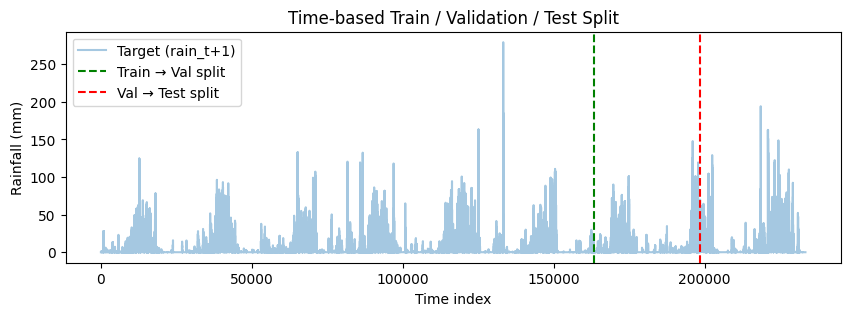

In [ ]:
# ==============================
# PHASE 4
# Train / Val / Test split (Time-based)
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# Ensure correct time order
df_sorted = df.sort_values(["year", "month", "day"]).reset_index(drop=True)

X_sorted = df_sorted.drop(columns=[TARGET_COL])
y_sorted = df_sorted[TARGET_COL]

# Split ratios
n = len(df_sorted)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

# Create splits
X_train = X_sorted.iloc[:train_end]
y_train = y_sorted.iloc[:train_end]

X_val = X_sorted.iloc[train_end:val_end]
y_val = y_sorted.iloc[train_end:val_end]

X_test = X_sorted.iloc[val_end:]
y_test = y_sorted.iloc[val_end:]

# Print split details
print("✅ Time-based split completed")
print(f"Train size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size: {X_test.shape}")

# ------------------------------
# Visualization: split timeline
# ------------------------------
plt.figure(figsize=(10, 3))
plt.plot(range(n), y_sorted, alpha=0.4, label="Target (rain_t+1)")
plt.axvline(train_end, color="green", linestyle="--", label="Train → Val split")
plt.axvline(val_end, color="red", linestyle="--", label="Val → Test split")
plt.title("Time-based Train / Validation / Test Split")
plt.xlabel("Time index")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()


In [ ]:
# ==============================
# PHASE 4
# Recreate train/val/test splits
# ==============================

# Sort by time to ensure correct temporal split
df = df.sort_values(["year", "month", "day"]).reset_index(drop=True)

# Split ratios
train_ratio = 0.70
val_ratio   = 0.15

n = len(df)
train_end = int(n * train_ratio)
val_end   = int(n * (train_ratio + val_ratio))

# Create splits
train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

# Verification
print("✅ Train / Validation / Test recreated")
print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)


✅ Train / Validation / Test recreated
Train size: (163396, 25)
Validation size: (35014, 25)
Test size: (35014, 25)


In [ ]:
# ================================
# PHASE 4
# Feature / Target separation
# ================================

TARGET_COL = "rain_t_plus_1"

# Split features and target
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_val = val_df.drop(columns=[TARGET_COL])
y_val = val_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

# Sanity checks
print("✅ Feature–target separation completed\n")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTarget column check:")
print("Target in X_train:", TARGET_COL in X_train.columns)
print("Target in X_val:", TARGET_COL in X_val.columns)
print("Target in X_test:", TARGET_COL in X_test.columns)


✅ Feature–target separation completed

X_train shape: (163396, 24)
y_train shape: (163396,)
X_val shape: (35014, 24)
y_val shape: (35014,)
X_test shape: (35014, 24)
y_test shape: (35014,)

Target column check:
Target in X_train: False
Target in X_val: False
Target in X_test: False


In [ ]:
# ==============================
# PHASE 4
# Encoding + Scaling
# ==============================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify feature types
categorical_cols = ["district"]
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation & test
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Shapes check
print("✅ Encoding + scaling completed\n")
print("X_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)


✅ Encoding + scaling completed

X_train_processed shape: (163396, 95)
X_val_processed shape: (35014, 95)
X_test_processed shape: (35014, 95)


In [ ]:
# =========================================
# PHASE 4 : SAVE MODEL-READY DATA
# =========================================

import numpy as np
import joblib
import os

BASE_PATH = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project"

# Create folders if not exist
os.makedirs(f"{BASE_PATH}/data/features", exist_ok=True)
os.makedirs(f"{BASE_PATH}/models/scalers", exist_ok=True)

# -----------------------------
# Save processed feature arrays
# -----------------------------
np.save(f"{BASE_PATH}/data/features/X_train.npy", X_train_processed)
np.save(f"{BASE_PATH}/data/features/X_val.npy", X_val_processed)
np.save(f"{BASE_PATH}/data/features/X_test.npy", X_test_processed)

np.save(f"{BASE_PATH}/data/features/y_train.npy", y_train.values)
np.save(f"{BASE_PATH}/data/features/y_val.npy", y_val.values)
np.save(f"{BASE_PATH}/data/features/y_test.npy", y_test.values)

# -----------------------------
# Save preprocessing pipeline
# -----------------------------
joblib.dump(preprocessor, f"{BASE_PATH}/models/scalers/preprocessor.joblib")

print("✅ Phase 4 artifacts saved successfully")
print("📂 Features saved in: data/features/")
print("📂 Preprocessor saved in: models/scalers/")


✅ Phase 4 artifacts saved successfully
📂 Features saved in: data/features/
📂 Preprocessor saved in: models/scalers/


📊 Model Comparison (Validation Set)


,Model,RMSE,MAE,R2
1,Gradient Boosting,6.030380,2.509911,0.368375
2,Ridge Regression,6.135325,2.714322,0.346200
0,Random Forest,6.182746,2.612998,0.336054


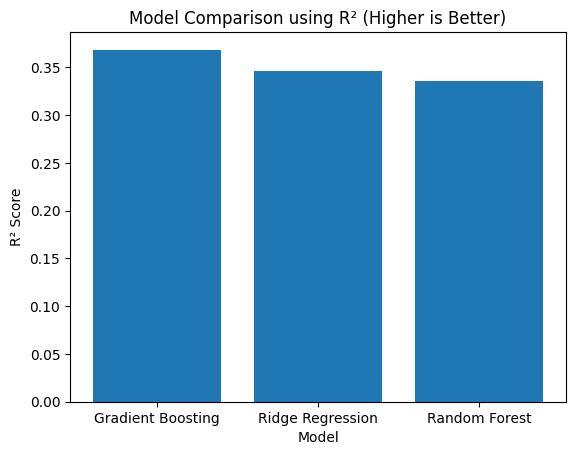

In [ ]:
# =====================================================
# PHASE 5
# Train + Evaluate + Compare Multiple Models
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# Define models
# -----------------------------
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=15,
        n_jobs=-1,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42
    ),
    "Ridge Regression": Ridge(alpha=1.0)
}

results = []

# -----------------------------
# Train & evaluate each model
# -----------------------------
for name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_val_pred = model.predict(X_val_processed)

    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae  = mean_absolute_error(y_val, y_val_pred)
    r2   = r2_score(y_val, y_val_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

# -----------------------------
# Results table
# -----------------------------
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("📊 Model Comparison (Validation Set)")
display(results_df)

# -----------------------------
# Visualization: R² comparison
# -----------------------------
plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison using R² (Higher is Better)")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.show()


In [ ]:
type(X_train_processed)


numpy.ndarray

In [ ]:
import numpy as np

np.isnan(X_train_processed).any()


np.False_

In [ ]:
print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)


(163396, 95)
(35014, 95)
(35014, 95)


In [ ]:

# ===============================
# PHASE 6
# XGBoost Baseline Model
# ===============================

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Safety checks
assert isinstance(X_train_processed, np.ndarray)
assert isinstance(X_val_processed, np.ndarray)

# Define model
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train ONLY on processed arrays
xgb_model.fit(X_train_processed, y_train)

# Predict on validation
y_val_pred = xgb_model.predict(X_val_processed)

# Metrics
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae  = mean_absolute_error(y_val, y_val_pred)
r2   = r2_score(y_val, y_val_pred)

print("📊 XGBoost – Validation Performance")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")


📊 XGBoost – Validation Performance
RMSE : 6.1423
MAE  : 2.5813
R²   : 0.3447


In [ ]:
# ================================
# PHASE 6  LIGHTGBM
# ================================

import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ----------------------------
# Train LightGBM Regressor
# ----------------------------
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train_processed, y_train)


# ----------------------------
# Validation Prediction
# ----------------------------
y_val_pred = lgb_model.predict(X_val_processed)

# ----------------------------
# Metrics
# ----------------------------
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae  = mean_absolute_error(y_val, y_val_pred)
r2   = r2_score(y_val, y_val_pred)

print("📊 LightGBM – Validation Performance")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5050
[LightGBM] [Info] Number of data points in the train set: 163396, number of used features: 95
[LightGBM] [Info] Start training from score 2.659951


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


📊 LightGBM – Validation Performance
RMSE : 6.1633
MAE  : 2.5359
R²   : 0.3402


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5050
[LightGBM] [Info] Number of data points in the train set: 163396, number of used features: 95
[LightGBM] [Info] Start training from score 2.659951


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


📊 Hybrid Stacking Model – Validation Performance
RMSE : 6.0820
MAE  : 2.4433
R²   : 0.3575


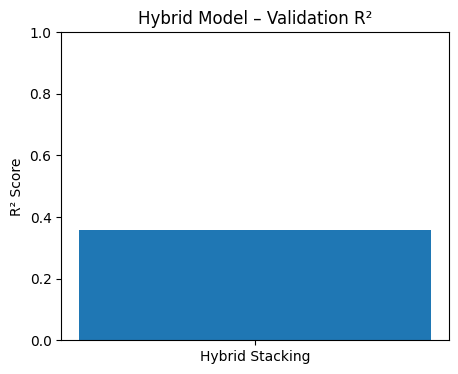

In [ ]:
# =====================================================
# PHASE 6.5 – HYBRID STACKING (TRAIN + STACK IN SESSION)
# =====================================================

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

# -----------------------------------------------------
# 1. Train base models (light, fast configs)
# -----------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=120,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)
xgb_model.fit(X_train_processed, y_train)
lgbm_model.fit(X_train_processed, y_train)

# -----------------------------------------------------
# 2. Collect validation predictions
# -----------------------------------------------------

rf_val_pred   = rf_model.predict(X_val_processed)
xgb_val_pred  = xgb_model.predict(X_val_processed)
lgbm_val_pred = lgbm_model.predict(X_val_processed)

X_val_stack = np.column_stack([
    rf_val_pred,
    xgb_val_pred,
    lgbm_val_pred
])

# -----------------------------------------------------
# 3. Train meta-model
# -----------------------------------------------------

meta_model = Ridge(alpha=1.0)
meta_model.fit(X_val_stack, y_val)

hybrid_val_pred = meta_model.predict(X_val_stack)

# -----------------------------------------------------
# 4. Evaluation
# -----------------------------------------------------

rmse = np.sqrt(mean_squared_error(y_val, hybrid_val_pred))
mae  = mean_absolute_error(y_val, hybrid_val_pred)
r2   = r2_score(y_val, hybrid_val_pred)

print("📊 Hybrid Stacking Model – Validation Performance")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# -----------------------------------------------------
# 5. Visualization
# -----------------------------------------------------

plt.figure(figsize=(5,4))
plt.bar(["Hybrid Stacking"], [r2])
plt.ylabel("R² Score")
plt.title("Hybrid Model – Validation R²")
plt.ylim(0, 1)
plt.show()


In [ ]:
# =====================================================
# PHASE 7
# Create Rain / No-Rain Binary Target
# =====================================================

import pandas as pd
import numpy as np

# Copy dataset to avoid overwriting
df_phase7 = df.copy()

# -----------------------------------------------------
# 1. Create binary rain target
# -----------------------------------------------------
# 1 = Rain, 0 = No Rain
df_phase7["rain_binary"] = (df_phase7["rain_t_plus_1"] >= 1.0).astype(int)

# -----------------------------------------------------
# 2. Quick sanity checks
# -----------------------------------------------------
print("✅ Rain / No-Rain target created")

print("\nClass distribution:")
print(df_phase7["rain_binary"].value_counts())

print("\nClass percentage:")
print(df_phase7["rain_binary"].value_counts(normalize=True) * 100)

# Preview
df_phase7[["rain_t_plus_1", "rain_binary"]].head()


✅ Rain / No-Rain target created

Class distribution:
rain_binary
0    169524
1     63900
Name: count, dtype: int64

Class percentage:
rain_binary
0    72.624923
1    27.375077
Name: proportion, dtype: float64


,rain_t_plus_1,rain_binary
0,0.00,0
1,0.00,0
2,0.00,0
3,0.00,0
4,0.02,0


In [ ]:
# =====================================================
# PHASE 7
# Time-based Train / Val / Test Split (Classification)
# =====================================================

# Ensure data is sorted by time
df_phase7 = df_phase7.sort_values(["year", "month", "day"]).reset_index(drop=True)

TARGET_COL = "rain_binary"

# -----------------------------------------------------
# 1. Define split indices (70 / 15 / 15)
# -----------------------------------------------------
n = len(df_phase7)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_phase7.iloc[:train_end]
val_df   = df_phase7.iloc[train_end:val_end]
test_df  = df_phase7.iloc[val_end:]

# -----------------------------------------------------
# 2. Feature / target separation
# -----------------------------------------------------
X_train = train_df.drop(columns=[TARGET_COL, "rain_t_plus_1"])
y_train = train_df[TARGET_COL]

X_val = val_df.drop(columns=[TARGET_COL, "rain_t_plus_1"])
y_val = val_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL, "rain_t_plus_1"])
y_test = test_df[TARGET_COL]

# -----------------------------------------------------
# 3. Sanity checks
# -----------------------------------------------------
print("✅ Phase 7 classification split completed\n")

print("Train size:", X_train.shape, "| Rain %:", y_train.mean() * 100)
print("Validation size:", X_val.shape, "| Rain %:", y_val.mean() * 100)
print("Test size:", X_test.shape, "| Rain %:", y_test.mean() * 100)


✅ Phase 7 classification split completed

Train size: (163396, 24) | Rain %: 26.242992484516144
Validation size: (35014, 24) | Rain %: 28.19158051065288
Test size: (35014, 24) | Rain %: 31.841549094647853


In [ ]:
# =====================================================
# PHASE 7
# Encoding + Scaling (Rain / No-Rain Classification)
# =====================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# -----------------------------------------------------
# 1. Identify feature types
# -----------------------------------------------------
categorical_cols = ["district"]
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

# -----------------------------------------------------
# 2. Build preprocessing pipeline
# -----------------------------------------------------
preprocessor_cls = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

# -----------------------------------------------------
# 3. Fit on TRAIN only
# -----------------------------------------------------
X_train_cls = preprocessor_cls.fit_transform(X_train)

# -----------------------------------------------------
# 4. Transform VAL & TEST
# -----------------------------------------------------
X_val_cls = preprocessor_cls.transform(X_val)
X_test_cls = preprocessor_cls.transform(X_test)

# -----------------------------------------------------
# 5. Checks
# -----------------------------------------------------
print("✅ Encoding + scaling completed (classification)\n")
print("X_train_cls:", X_train_cls.shape)
print("X_val_cls  :", X_val_cls.shape)
print("X_test_cls :", X_test_cls.shape)


✅ Encoding + scaling completed (classification)

X_train_cls: (163396, 95)
X_val_cls  : (35014, 95)
X_test_cls : (35014, 95)


In [ ]:
# =====================================================
# PHASE 7 – FIX BINARY TARGET VARIABLES
# =====================================================

# Reuse already existing targets
y_train_bin = y_train
y_val_bin   = y_val

# Optional check
print("✅ Binary targets ready")
print("y_train_bin unique values:", y_train_bin.unique())
print("y_val_bin unique values:", y_val_bin.unique())


✅ Binary targets ready
y_train_bin unique values: [0 1]
y_val_bin unique values: [1 0]


In [ ]:
# =====================================================
# PHASE 7 RAIN / NO-RAIN CLASSIFICATION MODELS
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# -----------------------------
# Define classifiers
# -----------------------------
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
}

results = []

# -----------------------------
# Train & evaluate
# -----------------------------
for name, model in classifiers.items():
    model.fit(X_train_cls, y_train_bin)

    y_val_pred = model.predict(X_val_cls)
    y_val_prob = model.predict_proba(X_val_cls)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val_bin, y_val_pred),
        "Precision": precision_score(y_val_bin, y_val_pred),
        "Recall": recall_score(y_val_bin, y_val_pred),
        "F1": f1_score(y_val_bin, y_val_pred),
        "ROC-AUC": roc_auc_score(y_val_bin, y_val_prob)
    })

# -----------------------------
# Results table
# -----------------------------
results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.867282,0.785464,0.728092,0.755691,0.920065
0,Logistic Regression,0.863969,0.785172,0.712390,0.747012,0.903239


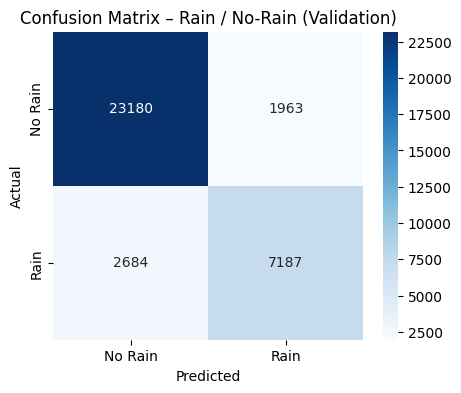

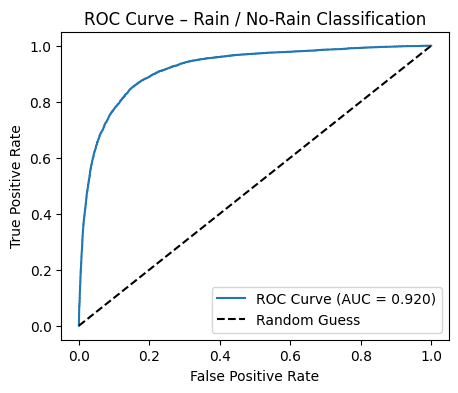

ROC-AUC (Validation): 0.9201


In [ ]:
# =====================================================
# PHASE 7
# Confusion Matrix + ROC Curve
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# -----------------------------------------------------
# 1. Get BEST trained classifier safely
# -----------------------------------------------------
best_clf = classifiers["Random Forest"]

# Predictions
y_val_pred = best_clf.predict(X_val_cls)
y_val_prob = best_clf.predict_proba(X_val_cls)[:, 1]

# -----------------------------------------------------
# 2. Confusion Matrix
# -----------------------------------------------------
cm = confusion_matrix(y_val_bin, y_val_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Rain / No-Rain (Validation)")
plt.show()

# -----------------------------------------------------
# 3. ROC Curve
# -----------------------------------------------------
fpr, tpr, _ = roc_curve(y_val_bin, y_val_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Rain / No-Rain Classification")
plt.legend()
plt.show()

print(f"ROC-AUC (Validation): {roc_auc:.4f}")


📊 Threshold Tuning Results (Validation Set)


,Threshold,Precision,Recall,F1
0,0.30,0.662944,0.871948,0.753216
1,0.35,0.695641,0.843987,0.762668
2,0.40,0.725185,0.805997,0.763458
3,0.45,0.755918,0.769932,0.762861
4,0.50,0.785464,0.728092,0.755691
5,0.55,0.812015,0.688785,0.745341


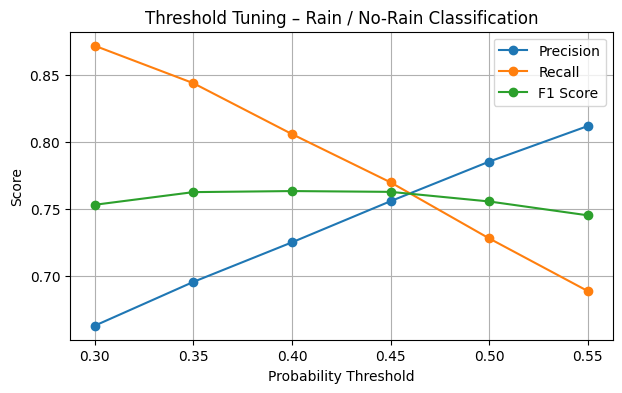

In [ ]:
# =====================================================
# PHASE 7  Threshold Tuning (Rain / No-Rain)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# -----------------------------------------------------
# 1. Get predicted probabilities (Rain = class 1)
# -----------------------------------------------------
y_val_prob = best_clf.predict_proba(X_val_cls)[:, 1]

# -----------------------------------------------------
# 2. Try different thresholds
# -----------------------------------------------------
thresholds = np.arange(0.30, 0.55, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_val_prob >= t).astype(int)

    precision = precision_score(y_val_bin, y_pred_t)
    recall    = recall_score(y_val_bin, y_pred_t)
    f1        = f1_score(y_val_bin, y_pred_t)

    results.append({
        "Threshold": t,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

results_df = pd.DataFrame(results)
print("📊 Threshold Tuning Results (Validation Set)")
display(results_df)

# -----------------------------------------------------
# 3. Visualization: Precision vs Recall
# -----------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(results_df["Threshold"], results_df["Precision"], marker="o", label="Precision")
plt.plot(results_df["Threshold"], results_df["Recall"], marker="o", label="Recall")
plt.plot(results_df["Threshold"], results_df["F1"], marker="o", label="F1 Score")

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning – Rain / No-Rain Classification")
plt.legend()
plt.grid(True)
plt.show()


📊 FINAL Rain / No-Rain Classifier (Validation Set)
Threshold : 0.4
Accuracy  : 0.8592
Precision : 0.7252
Recall    : 0.8060
F1 Score  : 0.7635
ROC-AUC   : 0.9201


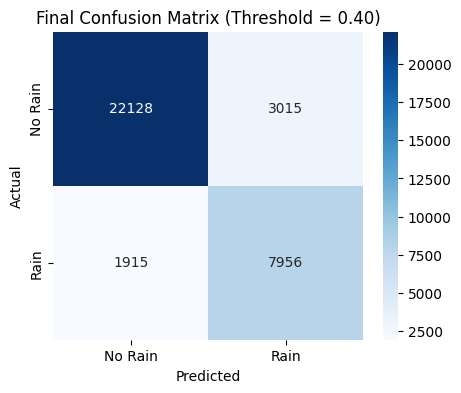

In [ ]:
# =====================================================
# PHASE 7
# Final Rain / No-Rain Classifier (Threshold = 0.40)
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# -----------------------------------------------------
# 1. Select BEST classifier (already trained)
# -----------------------------------------------------
best_clf = classifiers["Random Forest"]   # ✅ correct reference
THRESHOLD = 0.40

# -----------------------------------------------------
# 2. Probability predictions
# -----------------------------------------------------
y_val_proba = best_clf.predict_proba(X_val_cls)[:, 1]

# Apply tuned threshold
y_val_pred = (y_val_proba >= THRESHOLD).astype(int)

# -----------------------------------------------------
# 3. Final evaluation metrics
# -----------------------------------------------------
acc  = accuracy_score(y_val_bin, y_val_pred)
prec = precision_score(y_val_bin, y_val_pred)
rec  = recall_score(y_val_bin, y_val_pred)
f1   = f1_score(y_val_bin, y_val_pred)
auc  = roc_auc_score(y_val_bin, y_val_proba)

print("📊 FINAL Rain / No-Rain Classifier (Validation Set)")
print(f"Threshold : {THRESHOLD}")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

# -----------------------------------------------------
# 4. Confusion Matrix
# -----------------------------------------------------
cm = confusion_matrix(y_val_bin, y_val_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)
plt.title("Final Confusion Matrix (Threshold = 0.40)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Mounted at /content/drive
✅ Phase 3 features loaded
Shape: (233424, 25)
Splits recreated:
Train: (163390, 24) | Rain %: 47.87563498378113
Val  : (35020, 24) | Rain %: 47.875499714448885
Test : (35014, 24) | Rain %: 47.875135660021705
✅ Classifier trained (for FINAL test evaluation only)

📊 PHASE 7 – FINAL TEST PERFORMANCE
Accuracy : 0.8806
Precision: 0.8476
Recall   : 0.9151
F1-score : 0.8801
ROC-AUC  : 0.9587


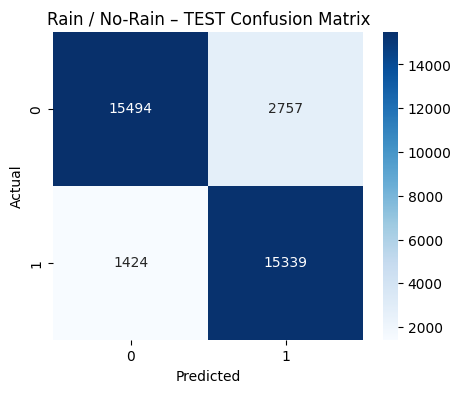

In [ ]:
# ============================================================
# PHASE 7 – FINAL TEST SET EVALUATION (RUNTIME-SAFE)
# ============================================================

# ---- 0. Runtime safety (Colab reconnect) ----
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ---- 1. Imports ----
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ---- 2. Load Phase 3 features ----
PHASE3_PATH = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/features/phase3_features.csv"
df = pd.read_csv(PHASE3_PATH)

print("✅ Phase 3 features loaded")
print("Shape:", df.shape)

# ---- 3. Create Rain / No-Rain target ----
df["rain_binary"] = (df["rain_t_plus_1"] > 0).astype(int)

# ---- 4. Define features ----
TARGET_BIN = "rain_binary"
DROP_COLS = ["rain_t_plus_1", TARGET_BIN]

X = df.drop(columns=DROP_COLS)
y = df[TARGET_BIN]

# ---- 5. Train / Val / Test split (same logic as Phase 7) ----
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print("Splits recreated:")
print("Train:", X_train.shape, "| Rain %:", y_train.mean()*100)
print("Val  :", X_val.shape,   "| Rain %:", y_val.mean()*100)
print("Test :", X_test.shape,  "| Rain %:", y_test.mean()*100)

# ---- 6. Preprocessing (same as Phase 7) ----
categorical_cols = ["district"]
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# ---- 7. Build classifier (Random Forest – chosen model) ----
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_clf)
    ]
)

# ---- 8. Train classifier (TRAIN only) ----
clf_pipeline.fit(X_train, y_train)

print("✅ Classifier trained (for FINAL test evaluation only)")

# ---- 9. TEST set prediction with threshold = 0.40 ----
THRESHOLD = 0.40

y_test_prob = clf_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)

# ---- 10. Metrics ----
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)
roc  = roc_auc_score(y_test, y_test_prob)

print("\n📊 PHASE 7 – FINAL TEST PERFORMANCE")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")

# ---- 11. Confusion Matrix ----
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Rain / No-Rain – TEST Confusion Matrix")
plt.show()


In [1]:
# ======================================================
# PHASE 10
# Save FINAL Rain / No-Rain Classifier (Production Ready)
# ======================================================

import os
import joblib
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -----------------------------
# Mount Drive (safe reconnect)
# -----------------------------
if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")

# -----------------------------
# Paths
# -----------------------------
BASE_DIR = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project"
FEATURES_PATH = f"{BASE_DIR}/data/features/phase3_features.csv"
MODEL_DIR = f"{BASE_DIR}/models/phase7_rain_classifier"

os.makedirs(MODEL_DIR, exist_ok=True)

# -----------------------------
# Load features
# -----------------------------
df = pd.read_csv(FEATURES_PATH)

# Recreate target (same Phase 7 rule)
df["rain_binary"] = (df["rain_t_plus_1"] > 0).astype(int)

# -----------------------------
# Train / Val / Test split (same logic)
# -----------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["rain_binary"],
    random_state=42
)

# -----------------------------
# Features & target
# -----------------------------
X_train = train_df.drop(columns=["rain_binary"])
y_train = train_df["rain_binary"]

# -----------------------------
# Preprocessing
# -----------------------------
categorical_cols = ["district"]
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# -----------------------------
# Final Classifier (Phase 7 best)
# -----------------------------
classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", classifier)
])

# -----------------------------
# Train FINAL model
# -----------------------------
pipeline.fit(X_train, y_train)

# -----------------------------
# Save artifacts
# -----------------------------
joblib.dump(pipeline, f"{MODEL_DIR}/rain_no_rain_model.pkl")
joblib.dump(preprocessor, f"{MODEL_DIR}/classifier_preprocessor.pkl")

THRESHOLD = 0.40
with open(f"{MODEL_DIR}/threshold.txt", "w") as f:
    f.write(str(THRESHOLD))

print("✅ FINAL Rain / No-Rain model saved successfully")
print("📂 Model directory:", MODEL_DIR)
print("📌 Threshold:", THRESHOLD)


Mounted at /content/drive
✅ FINAL Rain / No-Rain model saved successfully
📂 Model directory: /content/drive/MyDrive/UP_Rainfall_Prediction_Project/models/phase7_rain_classifier
📌 Threshold: 0.4
